# Intro to MLOps — hands-on (notebook)

Notebook version of `train.py`. Track an ML experiment with MLflow, then
compare runs in the UI.

- Tutorial: <https://jienweng.github.io/notes/intro-to-mlops-tutorial/>
- Slides:   <https://jienweng.github.io/slides/2026/intro-to-mlops/>

**How to use this notebook**
1. `pip install -r requirements.txt`
2. Run all cells. One MLflow run is logged.
3. Change `C` (e.g. to `0.01`), run again — now you have a second run.
4. In a terminal: `mlflow ui --backend-store-uri sqlite:///mlflow.db`,
   open <http://127.0.0.1:5000>, and **compare the two runs**.

## Setup

In [1]:
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Local SQLite store (recommended on MLflow 3.x); artifacts go to ./mlruns
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('intro-to-mlops')

/Users/jienweng/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/Volumes/littleSSD/jienweng/Projects/mlops-tutorial/mlruns/1', creation_time=1782812517967, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782812517967, lifecycle_stage='active', name='intro-to-mlops', tags={}, trace_location=None, workspace='default'>

## Data

In [2]:
# Load as a DataFrame so we can inspect column names, dtypes, and values
data = load_breast_cancer(as_frame=True)
X = data.data                 # 30 numeric features (pandas DataFrame)
y = data.target               # 0 = malignant, 1 = benign
target_names = data.target_names

# Combined frame (features + label) — handy for EDA below
df = X.copy()
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Explore the data (EDA)

Before training, sanity-check what we're actually feeding the model: how many
rows/columns, what the columns are, their types and ranges, whether anything is
missing, how balanced the classes are, and which features track the label.

In [3]:
# Shape + a peek at the columns
print(f'Rows: {df.shape[0]}   Columns: {df.shape[1]} ({X.shape[1]} features + target)')
print(f'Target labels: {dict(enumerate(target_names))}')
df.head()

Rows: 569   Columns: 31 (30 features + target)
Target labels: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
# Columns, dtypes, and non-null counts — confirms every column is numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [11]:
# Missing-value check — the model can't be trusted if inputs are incomplete
missing = df.isna().sum()
if missing.any():
    print('Missing values:')
    print(missing[missing > 0])
else:
    print('No missing values')

No missing values


In [12]:
# Summary statistics — watch the very different scales across features
# (a hint that scaling can help linear models)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


target
malignant    212
benign       357
Name: count, dtype: int64
Benign fraction: 62.7%


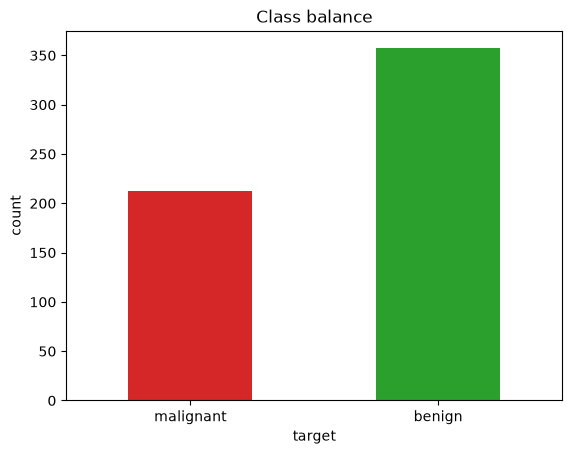

In [9]:
# Class balance — is one class much rarer than the other?
counts = df['target'].value_counts().sort_index()
print(counts.rename(index=dict(enumerate(target_names))))
print(f'Benign fraction: {y.mean():.1%}')

ax = counts.plot(kind='bar', color=['#d62728', '#2ca02c'])
ax.set_xticklabels(target_names, rotation=0)
ax.set_ylabel('count')
plt.title('Class balance')
plt.show()

In [13]:
# Which features track the label most strongly?
corr = (df.corr(numeric_only=True)['target']
          .drop('target')
          .sort_values(key=abs, ascending=False))
print('Top 10 features by |correlation| with target:')
corr.head(10)

Top 10 features by |correlation| with target:


worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64

## Train, evaluate, and log one run

Change `C` and re-run this cell to produce a second run to compare.

2026/07/01 16:44:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run: accuracy=0.9649, f1=0.9722


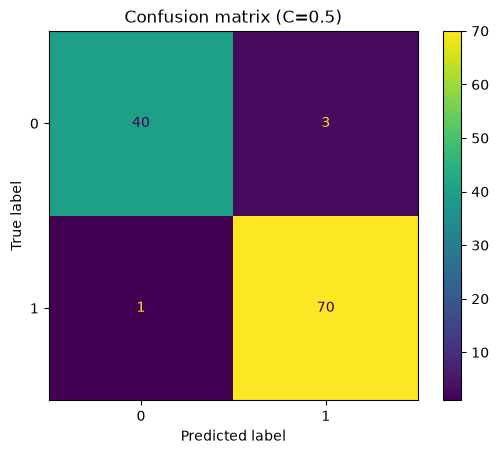

In [15]:
C = 0.5  # inverse regularisation strength — try 0.01 on a second run

with mlflow.start_run(run_name=f'logreg-C={C}'):
    model = LogisticRegression(C=C, max_iter=10_000)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('C', C)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('f1', f1)
    mlflow.sklearn.log_model(model, name='model')

    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(f'Confusion matrix (C={C})')
    plt.savefig('confusion_matrix.png', bbox_inches='tight')
    mlflow.log_artifact('confusion_matrix.png')

    print(f'Logged run: accuracy={acc:.4f}, f1={f1:.4f}')

## Compare runs

After logging at least two runs, launch the UI from a terminal:

```shell
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Open <http://127.0.0.1:5000>, select the two runs, and click **Compare**.

**Tip:** add `mlflow.sklearn.autolog()` before `fit()` to capture
params, metrics, and the model automatically in one line.